EXIF Centre: lat=28.44059163888889, lon=80.92534861111112
Adjusted Centre (shifted 4.7 m along bearing 175°):
    lat=28.440549391671833, lon=80.92535279278177
Measured shift from original center: 4.70 meters
Random pixel: x=1450, y=458
Mirror pixel (computed from image centre): x=150, y=842
Pixel offset: east = 14.300 m, north = 4.224 m
Computed pixel offset distance: 14.911 m, Bearing = 73.54°
Corrected pixel offset bearing (after subtracting 25°): 48.54°


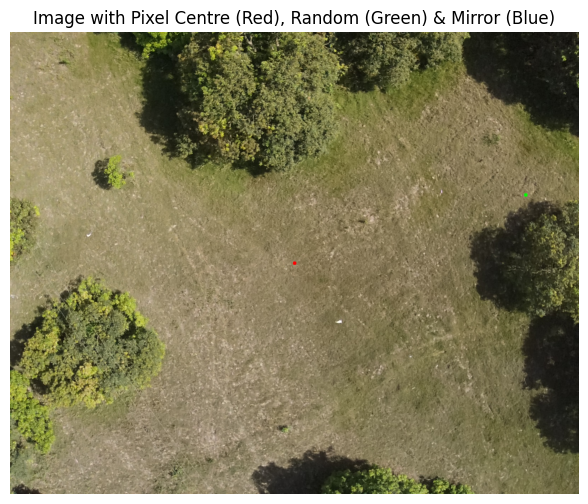

Adjusted centre, random point, and mirror point data saved to 'points_latlon_Test24.csv'


In [1]:
import random
import math
import csv
import numpy as np
import cv2
from PIL import Image, ExifTags
import matplotlib.pyplot as plt
from geopy.distance import distance as geopy_distance

def convert_to_degrees(value):
    """
    Convert an EXIF GPS coordinate to degrees as a float.
    If the value is a tuple/list with three elements (degrees, minutes, seconds),
    it converts each element to float and computes the total degrees.
    Otherwise, it converts the single value directly.
    """
    if isinstance(value, (tuple, list)) and len(value) == 3:
        d = float(value[0])
        m = float(value[1])
        s = float(value[2])
        return d + (m / 60.0) + (s / 3600.0)
    else:
        return float(value)

# ----- 1. Read the image and extract EXIF GPS data -----
image_path = "Test_Image/DJI_0080.JPG"  # Change this to your image file path
pil_image = Image.open(image_path)

exif_data = pil_image._getexif()
if exif_data is None:
    raise Exception("No EXIF metadata found in the image.")

# Create a dictionary with decoded EXIF tags.
exif = {}
for tag, value in exif_data.items():
    decoded = ExifTags.TAGS.get(tag, tag)
    exif[decoded] = value

gps_info = exif.get("GPSInfo", None)
if gps_info is None:
    raise Exception("No GPSInfo found in EXIF metadata.")

# Extract latitude and longitude from GPSInfo.
exif_lat = convert_to_degrees(gps_info[2])
if gps_info[1] != "N":
    exif_lat = -exif_lat

exif_lon = convert_to_degrees(gps_info[4])
if gps_info[3] != "E":
    exif_lon = -exif_lon

print(f"EXIF Centre: lat={exif_lat}, lon={exif_lon}")
orig_center = (exif_lat, exif_lon)

# ----- 2. Shift the EXIF centre by 3.47 meters along a bearing of 195° -----
shift_distance = 4.7  # in meters
shift_bearing = 175    # in degrees (15° west of due south)
adjusted_center = geopy_distance(meters=shift_distance).destination(orig_center, shift_bearing)
adjusted_center_lat = adjusted_center.latitude
adjusted_center_lon = adjusted_center.longitude

# Verify the shift distance.
measured_shift = geopy_distance(orig_center, (adjusted_center_lat, adjusted_center_lon)).meters
print(f"Adjusted Centre (shifted {shift_distance} m along bearing {shift_bearing}°):")
print(f"    lat={adjusted_center_lat}, lon={adjusted_center_lon}")
print(f"Measured shift from original center: {measured_shift:.2f} meters")

# ----- 3. Determine the image centre (pixel coordinates) and select a random pixel -----
width, height = pil_image.size
center_x, center_y = width // 2, height // 2  # Geometric centre in pixels.

# Choose a random pixel from the image.
random_x = random.randint(0, width - 1)
random_y = random.randint(0, height - 1)
print(f"Random pixel: x={random_x}, y={random_y}")

# Calculate the mirror pixel (reflection about the image's pixel centre).
mirror_x = 2 * center_x - random_x
mirror_y = 2 * center_y - random_y
print(f"Mirror pixel (computed from image centre): x={mirror_x}, y={mirror_y}")

# ----- 4. Compute pixel displacement from the image centre -----
dx = random_x - center_x
dy = random_y - center_y

# ----- 5. Convert pixel displacement to geographic offsets -----
meters_per_pixel = 0.022  # conversion factor
offset_east_meters = dx * meters_per_pixel
offset_north_meters = -dy * meters_per_pixel  # positive dy means southward

# Compute the overall distance and bearing from the pixel offset.
distance_offset = math.sqrt(offset_east_meters**2 + offset_north_meters**2)
if distance_offset == 0:
    bearing_offset = 0
else:
    # Compute bearing (clockwise from north)
    bearing_offset = math.degrees(math.atan2(offset_east_meters, offset_north_meters)) % 360

print(f"Pixel offset: east = {offset_east_meters:.3f} m, north = {offset_north_meters:.3f} m")
print(f"Computed pixel offset distance: {distance_offset:.3f} m, Bearing = {bearing_offset:.2f}°")

# ----- 5a. Apply a fixed correction to the computed bearing -----
# Change the value of correction_degrees to adjust the bearing.
correction_degrees = 25  # try adjusting this value until the point is in the correct direction
corrected_bearing_offset = (bearing_offset - correction_degrees) % 360
print(f"Corrected pixel offset bearing (after subtracting {correction_degrees}°): {corrected_bearing_offset:.2f}°")

# ----- 6. Calculate geographic coordinates for the random and mirror points -----


mirror_bearing = (corrected_bearing_offset + 180) % 360
mirror_geo_point = geopy_distance(meters=distance_offset).destination(
    (adjusted_center_lat, adjusted_center_lon), mirror_bearing)
mirror_geo_lat = mirror_geo_point.latitude
mirror_geo_lon = mirror_geo_point.longitude

# ----- 7. Mark the centres and points on the image for visualization -----
img_np = np.array(pil_image)
img_marked = img_np.copy()

centre_point = (center_x, center_y)
random_point_pix = (random_x, random_y)

cv2.circle(img_marked, centre_point, radius=5, color=(255, 0, 0), thickness=-1)    # Centre in red.
cv2.circle(img_marked, random_point_pix, radius=5, color=(0, 255, 0), thickness=-1)  # Random point in green.

plt.figure(figsize=(8, 6))
plt.imshow(img_marked)
plt.title("Image with Pixel Centre (Red), Random (Green) & Mirror (Blue)")
plt.axis("off")
plt.show()

# ----- 8. Save the adjusted centre and computed points to a CSV file -----
csv_filename = "points_latlon_Test24.csv"
with open(csv_filename, "w", newline="") as csvfile:
    csv_writer = csv.writer(csvfile)
    csv_writer.writerow(["Name", "Pixel_X", "Pixel_Y", "Latitude", "Longitude"])
    csv_writer.writerow(["Adjusted Centre", center_x, center_y, adjusted_center_lat, adjusted_center_lon])
    csv_writer.writerow(["Mirror", mirror_x, mirror_y, mirror_geo_lat, mirror_geo_lon])
print(f"Adjusted centre, random point, and mirror point data saved to '{csv_filename}'")

